# Cropland LightGBM latent-regime mixture-of-experts

    このnotebookは、線形回帰やRidgeではなく、**LightGBMだけ**を使って、
    根源的生産要素に対する反応が異なる農業レジームを推定します。

    各レジームに2段階LightGBMを持たせ、LightGBMの予測誤差にもとづいて
    レジーム所属を反復更新します。通常のKMeansで説明変数だけを分ける方法ではありません。


## 【セル1】データ読み込み・共通設定


In [1]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
YEAR = 2024
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5

WX_RADII_KM = (50, 100)
WX_SOURCE_FEATURES = [
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_rainfed_value_top5",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",
]
INCLUDE_SLOPE_WX = False
MIN_VALID_NEIGHBOR_FRACTION = 0.25
SAVE_WX_RASTERS = True

EARTH_RADIUS_KM = 6371.0088
MORAN_K = 8
MORAN_MAX_N = 50_000


def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError(
        "Required cache not found: " + ", ".join(names)
    )


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
SHAPE = (len(lat), len(lon))

cropland_raw = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland_2024 = np.asarray(cropland_raw[year_index], dtype=np.float32).copy()
cropland_2024[~np.isfinite(cropland_2024)] = np.nan

population_density_2024 = load_cache("population_density_2024.npy")
elevation_m = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
exclusion = load_cache("exclusion_5min_mode.npy")
city_time_20k_min = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time_any_min = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas_p10 = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
distance_river_gt10 = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)
rainfed_value_top5 = load_cache(
    "rainfed_value_top5_usd_per_ha_checked_36crops.npy",
    "rainfed_value_top5_checked_36crops.npy",
)
irrigated_value_top5 = load_cache(
    "irrigated_value_top5_usd_per_ha_checked_36crops.npy",
    "irrigated_value_top5_checked_36crops.npy",
)
rainfed_calorie_top5 = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie_top5 = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

land_mask = (
    np.isfinite(elevation_m)
    & np.isfinite(cropland_2024)
    & np.isfinite(population_density_2024)
    & (population_density_2024 >= 0)
)
presence = land_mask & (cropland_2024 > PRESENCE_THRESHOLD)

rng = np.random.default_rng(RANDOM_SEED)
pos_flat = np.flatnonzero(presence.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence).ravel())
pos_sample = rng.choice(pos_flat, min(N_POS_SAMPLE, len(pos_flat)), replace=False)
zero_sample = rng.choice(zero_flat, min(N_ZERO_SAMPLE, len(zero_flat)), replace=False)
sample_flat = np.concatenate([pos_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, SHAPE)


def take(array):
    return np.asarray(array[rows, cols])


sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland_2024).astype(np.float32),
    "presence": (take(cropland_2024) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation_m).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": np.nan_to_num(take(exclusion), nan=-1).astype(np.int16),
    "log_pop_density_2024": safe_log1p(take(population_density_2024)),
    "log_city_time_20k_min": safe_log1p(take(city_time_20k_min)),
    "log_port_time_any_min": safe_log1p(take(port_time_any_min)),
    "log_glofas_p10_2020": safe_log1p(take(glofas_p10)),
    "log_distance_river_gt10_2020": safe_log1p(take(distance_river_gt10)),
    "log_rainfed_value_top5": safe_log1p(take(rainfed_value_top5)),
    "log_rainfed_calorie_top5": safe_log1p(take(rainfed_calorie_top5)),
    "log_irrigation_value_gain_top5": safe_log1p(
        np.maximum(take(irrigated_value_top5) - take(rainfed_value_top5), 0)
    ),
    "log_irrigation_calorie_gain_top5": safe_log1p(
        np.maximum(take(irrigated_calorie_top5) - take(rainfed_calorie_top5), 0)
    ),
}).replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

base_feature_cols = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",
    "log_rainfed_value_top5",
    "log_rainfed_calorie_top5",
    "log_irrigation_value_gain_top5",
    "log_irrigation_calorie_gain_top5",
]

print("grid:", SHAPE)
print("sample rows:", len(sample))
print("sample presence share:", float(sample["presence"].mean()))

load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: exclusion_5min_mode.npy
load cache: rainfed_value_top5_usd_per_ha_checked_36crops.npy
load cache: irrigated_value_top5_usd_per_ha_checked_36crops.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
grid: (2160, 4320)
sample rows: 240000
sample presence share: 0.5


## 【セル2】50km・100kmの周辺変数（WX）作成


In [2]:
# 既存のWXキャッシュを読み込むだけ
# キャッシュがない場合は、ここでは再計算せずエラーにする。

sample_rows = sample["row"].to_numpy(dtype=int)
sample_cols = sample["col"].to_numpy(dtype=int)
wx_feature_cols = []

for radius_km in WX_RADII_KM:
    for source_name in WX_SOURCE_FEATURES:
        wx_name = f"wx_{radius_km}km_{source_name}"
        cache_path = OUTPUT_DIR / f"{wx_name}.npy"

        if not cache_path.exists():
            raise FileNotFoundError(
                "WXキャッシュがありません。再計算は行わず停止します: "
                f"{cache_path}"
            )

        print("load WX cache:", cache_path.name)
        wx_raster = np.load(cache_path, mmap_mode="r")

        if wx_raster.shape != SHAPE:
            raise ValueError(
                f"WXキャッシュのshapeが不正です: {cache_path} "
                f"{wx_raster.shape} != {SHAPE}"
            )

        sample[wx_name] = np.asarray(
            wx_raster[sample_rows, sample_cols],
            dtype=np.float32,
        )
        wx_feature_cols.append(wx_name)

print("WX feature count:", len(wx_feature_cols))


load WX cache: wx_50km_log_pop_density_2024.npy
load WX cache: wx_50km_log_city_time_20k_min.npy
load WX cache: wx_50km_log_port_time_any_min.npy
load WX cache: wx_50km_log_rainfed_value_top5.npy
load WX cache: wx_50km_log_glofas_p10_2020.npy
load WX cache: wx_50km_log_distance_river_gt10_2020.npy
load WX cache: wx_100km_log_pop_density_2024.npy
load WX cache: wx_100km_log_city_time_20k_min.npy
load WX cache: wx_100km_log_port_time_any_min.npy
load WX cache: wx_100km_log_rainfed_value_top5.npy
load WX cache: wx_100km_log_glofas_p10_2020.npy
load WX cache: wx_100km_log_distance_river_gt10_2020.npy
WX feature count: 12


## 【セル3】分析サンプル・空間fold作成


In [3]:
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=base_feature_cols + wx_feature_cols)
    .reset_index(drop=True)
)
analysis_sample = sample.copy()
y_all = analysis_sample["presence"].to_numpy(dtype=np.uint8)
groups = analysis_sample["spatial_block"].to_numpy()

if analysis_sample["presence"].nunique() < 2:
    raise ValueError("Both presence classes are required.")
target_prior = float(presence.sum() / land_mask.sum())

feature_cols_by_model = {
    "baseline": base_feature_cols,
    "wx": base_feature_cols + wx_feature_cols,
}

try:
    cell_area_km2 = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        cell_area_km2[
            analysis_sample["row"].to_numpy(int),
            analysis_sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_pop = int(presence.sum())
    n_zero_pop = int(land_mask.sum() - presence.sum())
    n_pos_samp = int((y_all == 1).sum())
    n_zero_samp = int((y_all == 0).sum())
    area_weight = np.where(
        y_all == 1,
        n_pos_pop / max(n_pos_samp, 1),
        n_zero_pop / max(n_zero_samp, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting skipped.")
    area_weight = None

splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        analysis_sample,
        y_all,
        groups=groups,
    )
)
print("analysis rows:", len(analysis_sample))
print("spatial blocks:", analysis_sample["spatial_block"].nunique())
print("target prior:", target_prior)

analysis rows: 240000
spatial blocks: 291
target prior: 0.3658932992121897


In [4]:
# raw再推定セルで必要になる重み設定
weight_specs = {"unweighted_sample": None}
if area_weight is not None:
    weight_specs["area_weighted_reweighted"] = area_weight


## 【セル4】二段階LightGBMの関数定義

baseline・WXのOOF再推定は省略し、後続のrawモデルとレジームモデルが使う関数だけを定義します。


In [5]:
def adjust_probability_prior_shift(probability, sample_prior, target_prior, eps=1e-6):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    target_prior = float(np.clip(target_prior, eps, 1 - eps))
    odds = probability / (1 - probability)
    odds *= (
        target_prior / (1 - target_prior)
    ) / (
        sample_prior / (1 - sample_prior)
    )
    return odds / (1 + odds)


def regression_summary(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[valid], y_pred[valid]
    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]
    mean_true = np.average(y_true, weights=weights)
    residual = y_true - y_pred
    ss_res = np.sum(weights * residual**2)
    ss_tot = np.sum(weights * (y_true - mean_true)**2)
    return {
        "n": int(len(y_true)),
        "observed_mean": float(mean_true),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "rmse": float(np.sqrt(np.average(residual**2, weights=weights))),
        "r2": float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


def classification_summary(y_true, probability, weights=None):
    y_true = np.asarray(y_true, dtype=np.uint8)
    probability = np.asarray(probability, dtype=float)
    valid = np.isfinite(probability)
    y_true, probability = y_true[valid], probability[valid]
    if weights is not None:
        weights = np.asarray(weights, dtype=float)[valid]
    return {
        "n": int(len(y_true)),
        "auc": float(roc_auc_score(y_true, probability, sample_weight=weights)),
        "average_precision": float(
            average_precision_score(y_true, probability, sample_weight=weights)
        ),
    }


def fit_predict_two_stage(train_df, test_df, features, fold_number):
    clf = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )
    clf.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=["exclusion_class"],
    )
    raw_probability = clf.predict_proba(test_df[features])[:, 1]
    calibrated_probability = adjust_probability_prior_shift(
        raw_probability,
        float(train_df["presence"].mean()),
        target_prior,
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    reg = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )
    reg.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=["exclusion_class"],
    )
    conditional = np.clip(reg.predict(test_df[features]), 0, 1)
    expected = calibrated_probability * conditional
    return raw_probability, calibrated_probability, conditional, expected




## 【セル5】raw crop-potential + WXモデルのOOF再推定

crop-potentialはraw値、周辺変数は既存のlog/WX仕様を使います。


In [6]:
# ============================================================
# 追加セル
# Crop potentialをraw値＋存在フラグで再学習
# raw_crop と raw_crop_wx を既存モデルと比較
# ============================================================

print("=" * 70)
print("RAW CROP-POTENTIAL RE-ESTIMATION")
print("=" * 70)

required_objects = [
    "analysis_sample",
    "splits",
    "fit_predict_two_stage",
    "regression_summary",
    "classification_summary",
    "feature_cols_by_model",
    "wx_feature_cols",
    "base_feature_cols",
    "area_weight",
    "weight_specs",
]

missing = [
    name for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"以下の変数がありません: {missing}\n"
        "先にセル1〜12を実行してください。"
    )


# ------------------------------------------------------------
# 1. 既存のanalysis_sampleをコピー
# ------------------------------------------------------------

raw_analysis_sample = analysis_sample.copy()

raw_rows = raw_analysis_sample["row"].to_numpy(dtype=int)
raw_cols = raw_analysis_sample["col"].to_numpy(dtype=int)


def sample_raster(array):
    return np.asarray(
        array[raw_rows, raw_cols],
        dtype=np.float32,
    )


def clean_positive_feature(values):
    """
    正の値だけをraw値として残す。
    非正値は0にする。
    同時に、存在フラグと欠測フラグも返す。
    """
    values = np.asarray(values, dtype=np.float32)

    finite = np.isfinite(values)
    exists = finite & (values > 0)
    missing = ~finite

    clean = np.where(
        exists,
        values,
        0.0,
    ).astype(np.float32)

    return (
        clean,
        exists.astype(np.uint8),
        missing.astype(np.uint8),
    )


# ------------------------------------------------------------
# 2. crop potentialのraw値を作成
# ------------------------------------------------------------

rainfed_value_sample = sample_raster(rainfed_value_top5)
irrigated_value_sample = sample_raster(irrigated_value_top5)

rainfed_calorie_sample = sample_raster(rainfed_calorie_top5)
irrigated_calorie_sample = sample_raster(irrigated_calorie_top5)


(
    rainfed_value_raw,
    rainfed_value_exists,
    rainfed_value_missing,
) = clean_positive_feature(rainfed_value_sample)

(
    rainfed_calorie_raw,
    rainfed_calorie_exists,
    rainfed_calorie_missing,
) = clean_positive_feature(rainfed_calorie_sample)


# ------------------------------------------------------------
# 3. 灌漑gainと符号付き差分を作成
# ------------------------------------------------------------

value_pair_valid = (
    np.isfinite(rainfed_value_sample)
    & np.isfinite(irrigated_value_sample)
)

calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)


# 符号付き差分
irrigation_value_delta_signed = np.where(
    value_pair_valid,
    irrigated_value_sample - rainfed_value_sample,
    0.0,
).astype(np.float32)

irrigation_calorie_delta_signed = np.where(
    calorie_pair_valid,
    irrigated_calorie_sample - rainfed_calorie_sample,
    0.0,
).astype(np.float32)


# 非負gain
irrigation_value_gain_raw = np.maximum(
    irrigation_value_delta_signed,
    0.0,
).astype(np.float32)

irrigation_calorie_gain_raw = np.maximum(
    irrigation_calorie_delta_signed,
    0.0,
).astype(np.float32)


# gainの存在フラグ
irrigation_value_gain_exists = (
    value_pair_valid
    & (irrigation_value_delta_signed > 0)
).astype(np.uint8)

irrigation_calorie_gain_exists = (
    calorie_pair_valid
    & (irrigation_calorie_delta_signed > 0)
).astype(np.uint8)


# 欠測フラグ
irrigation_value_gain_missing = (
    ~value_pair_valid
).astype(np.uint8)

irrigation_calorie_gain_missing = (
    ~calorie_pair_valid
).astype(np.uint8)


# ------------------------------------------------------------
# 4. DataFrameに追加
# ------------------------------------------------------------

raw_analysis_sample[
    "rainfed_value_top5_raw"
] = rainfed_value_raw

raw_analysis_sample[
    "rainfed_calorie_top5_raw"
] = rainfed_calorie_raw

raw_analysis_sample[
    "irrigation_value_gain_top5_raw"
] = irrigation_value_gain_raw

raw_analysis_sample[
    "irrigation_calorie_gain_top5_raw"
] = irrigation_calorie_gain_raw


raw_analysis_sample[
    "rainfed_value_top5_exists"
] = rainfed_value_exists

raw_analysis_sample[
    "rainfed_calorie_top5_exists"
] = rainfed_calorie_exists

raw_analysis_sample[
    "irrigation_value_gain_top5_exists"
] = irrigation_value_gain_exists

raw_analysis_sample[
    "irrigation_calorie_gain_top5_exists"
] = irrigation_calorie_gain_exists


raw_analysis_sample[
    "irrigation_value_delta_top5_signed"
] = irrigation_value_delta_signed

raw_analysis_sample[
    "irrigation_calorie_delta_top5_signed"
] = irrigation_calorie_delta_signed


raw_analysis_sample[
    "rainfed_value_top5_missing"
] = rainfed_value_missing

raw_analysis_sample[
    "rainfed_calorie_top5_missing"
] = rainfed_calorie_missing

raw_analysis_sample[
    "irrigation_value_gain_top5_missing"
] = irrigation_value_gain_missing

raw_analysis_sample[
    "irrigation_calorie_gain_top5_missing"
] = irrigation_calorie_gain_missing


# ------------------------------------------------------------
# 5. 新しいcrop potential feature list
# ------------------------------------------------------------

non_crop_base_cols = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_min",
]

# 実際の列名を確認
if "log_distance_river_gt10_min" not in raw_analysis_sample.columns:
    non_crop_base_cols[-1] = "log_distance_river_gt10_2020"


raw_crop_cols = [
    # rawの大きさ
    "rainfed_value_top5_raw",
    "rainfed_calorie_top5_raw",
    "irrigation_value_gain_top5_raw",
    "irrigation_calorie_gain_top5_raw",

    # 0か正値か
    "rainfed_value_top5_exists",
    "rainfed_calorie_top5_exists",
    "irrigation_value_gain_top5_exists",
    "irrigation_calorie_gain_top5_exists",

    # 灌漑による符号付き差分
    "irrigation_value_delta_top5_signed",
    "irrigation_calorie_delta_top5_signed",

    # 欠測フラグ
    "rainfed_value_top5_missing",
    "rainfed_calorie_top5_missing",
    "irrigation_value_gain_top5_missing",
    "irrigation_calorie_gain_top5_missing",
]


raw_crop_feature_cols = (
    non_crop_base_cols
    + raw_crop_cols
)


# ------------------------------------------------------------
# 6. raw版のcrop potential WXを作る
# ------------------------------------------------------------

# 既存のraw crop-potential WXキャッシュを読み込むだけ
# キャッシュがない場合は、ここでは再計算せずエラーにする。

raw_crop_wx_feature_cols = []

for radius_km in WX_RADII_KM:
    raw_wx_names = [
        f"wx_{radius_km}km_rainfed_value_top5_raw",
        f"wx_{radius_km}km_rainfed_value_exists_share",
    ]

    for wx_name in raw_wx_names:
        cache_path = OUTPUT_DIR / f"{wx_name}.npy"

        if not cache_path.exists():
            raise FileNotFoundError(
                "raw WXキャッシュがありません。再計算は行わず停止します: "
                f"{cache_path}"
            )

        print("load raw WX cache:", cache_path.name)
        wx_raster = np.load(cache_path, mmap_mode="r")

        if wx_raster.shape != SHAPE:
            raise ValueError(
                f"raw WXキャッシュのshapeが不正です: {cache_path} "
                f"{wx_raster.shape} != {SHAPE}"
            )

        raw_analysis_sample[wx_name] = np.asarray(
            wx_raster[raw_rows, raw_cols],
            dtype=np.float32,
        )
        raw_crop_wx_feature_cols.append(wx_name)


# 既存WXから、log版rainfed value WXだけ除外
non_crop_wx_feature_cols = [
    col
    for col in wx_feature_cols
    if "log_rainfed_value_top5" not in col
]


raw_crop_wx_feature_cols = (
    raw_crop_feature_cols
    + non_crop_wx_feature_cols
    + raw_crop_wx_feature_cols
)


feature_cols_raw_by_model = {
    "raw_crop": raw_crop_feature_cols,
    "raw_crop_wx": raw_crop_wx_feature_cols,
}


print()
print("raw_crop feature count:", len(raw_crop_feature_cols))
print("raw_crop_wx feature count:", len(raw_crop_wx_feature_cols))
print()
print("raw_crop features:")
print(raw_crop_feature_cols)
print()
print("raw_crop_wx features:")
print(raw_crop_wx_feature_cols)


# ------------------------------------------------------------
# 7. raw版Spatial OOF
# ------------------------------------------------------------

raw_oof = {
    model_name: {
        "fold": np.full(
            len(raw_analysis_sample),
            -1,
            dtype=np.int16,
        ),
        "presence_raw": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
        "presence_calibrated": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
        "fraction_conditional": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
        "fraction_expected": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
    }
    for model_name in feature_cols_raw_by_model
}


raw_fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):

    train_df = raw_analysis_sample.iloc[train_idx]
    test_df = raw_analysis_sample.iloc[test_idx]

    print()
    print("=" * 70)
    print(
        f"RAW MODEL FOLD {fold_number}/{N_SPLITS}"
    )
    print("=" * 70)

    for model_name, features in feature_cols_raw_by_model.items():

        print(
            f"training: {model_name} "
            f"({len(features)} features)"
        )

        raw_probability, calibrated_probability, conditional, expected = (
            fit_predict_two_stage(
                train_df,
                test_df,
                features,
                fold_number,
            )
        )

        raw_oof[model_name]["fold"][test_idx] = (
            fold_number
        )

        raw_oof[model_name]["presence_raw"][test_idx] = (
            raw_probability
        )

        raw_oof[model_name]["presence_calibrated"][test_idx] = (
            calibrated_probability
        )

        raw_oof[model_name]["fraction_conditional"][test_idx] = (
            conditional
        )

        raw_oof[model_name]["fraction_expected"][test_idx] = (
            expected
        )

        y_test = test_df[
            "presence"
        ].to_numpy(dtype=np.uint8)

        y_fraction = test_df[
            "cropland_fraction"
        ].to_numpy(dtype=float)

        positive_mask = y_test == 1

        combined_metrics = regression_summary(
            y_fraction,
            expected,
        )

        conditional_metrics = regression_summary(
            y_fraction[positive_mask],
            conditional[positive_mask],
        )

        stage1_metrics = classification_summary(
            y_test,
            raw_probability,
        )

        raw_fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "presence_auc": stage1_metrics["auc"],
            "presence_average_precision": (
                stage1_metrics["average_precision"]
            ),
            "combined_r2": combined_metrics["r2"],
            "combined_rmse": combined_metrics["rmse"],
            "combined_mae": combined_metrics["mae"],
            "conditional_r2": conditional_metrics["r2"],
            "conditional_rmse": conditional_metrics["rmse"],
            "conditional_mae": conditional_metrics["mae"],
        })

        del (
            raw_probability,
            calibrated_probability,
            conditional,
            expected,
        )

        gc.collect()


raw_fold_metrics_df = pd.DataFrame(
    raw_fold_rows
)




RAW CROP-POTENTIAL RE-ESTIMATION
load raw WX cache: wx_50km_rainfed_value_top5_raw.npy
load raw WX cache: wx_50km_rainfed_value_exists_share.npy
load raw WX cache: wx_100km_rainfed_value_top5_raw.npy
load raw WX cache: wx_100km_rainfed_value_exists_share.npy

raw_crop feature count: 22
raw_crop_wx feature count: 36

raw_crop features:
['elevation_m', 'slope', 'exclusion_class', 'log_pop_density_2024', 'log_city_time_20k_min', 'log_port_time_any_min', 'log_glofas_p10_2020', 'log_distance_river_gt10_2020', 'rainfed_value_top5_raw', 'rainfed_calorie_top5_raw', 'irrigation_value_gain_top5_raw', 'irrigation_calorie_gain_top5_raw', 'rainfed_value_top5_exists', 'rainfed_calorie_top5_exists', 'irrigation_value_gain_top5_exists', 'irrigation_calorie_gain_top5_exists', 'irrigation_value_delta_top5_signed', 'irrigation_calorie_delta_top5_signed', 'rainfed_value_top5_missing', 'rainfed_calorie_top5_missing', 'irrigation_value_gain_top5_missing', 'irrigation_calorie_gain_top5_missing']

raw_crop_wx

## 【セル6】LightGBMレジームモデルの設計

ここで推定するのは、入力値の似た地域ではなく、**同じ説明変数に対するクロップランド割合の反応が異なるグループ**です。

- 各レジームにStage 1（presence）とStage 2（conditional fraction）のLightGBMを持たせる
- 学習データ内では、各セルの所属確率を重みにして専門モデルを学習する
- 予測誤差が小さいレジームへ所属確率を更新する
- 最終的なテストデータのレジーム判定は、農地割合を使わず、説明変数だけからgate LightGBMで行う

内部更新はsoft assignmentですが、結果として各セルを `argmax` で一つのレジームに割り当てます。
これはLightGBM版のEM-like alternating estimationであり、前のRidgeベースMLEコードは使いません。


In [7]:
# ============================================================
# LightGBM latent regime mixture-of-experts: settings
# ============================================================
REGIME_MODEL_NAME = "raw_crop_wx"
REGIME_K_VALUES = (2, 3)
REGIME_EM_ITERATIONS = 3
REGIME_RANDOM_SEED = RANDOM_SEED + 7000
REGIME_WEIGHT_FLOOR = 1e-3
REGIME_SIGMA_FLOOR = 0.02
REGIME_OUTPUT_DIR = OUTPUT_DIR / "lightgbm_latent_regime_moe"
REGIME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REGIME_FEATURES = list(feature_cols_raw_by_model[REGIME_MODEL_NAME])
REGIME_CATEGORICAL_FEATURES = [
    col for col in ["exclusion_class"]
    if col in REGIME_FEATURES
]
print("Regime model:", REGIME_MODEL_NAME)
print("features:", len(REGIME_FEATURES))
print("K candidates:", REGIME_K_VALUES)
print("EM iterations per fold:", REGIME_EM_ITERATIONS)



Regime model: raw_crop_wx
features: 36
K candidates: (2, 3)
EM iterations per fold: 3


## 【セル7】LightGBMによるレジーム専門モデル

レジームごとに、presence分類器とconditional fraction回帰器を学習します。
Stage 2もLightGBMなので、レジーム内の反応は非線形です。

レジーム更新時の確率計算には、各専門モデルのStage 1のBernoulli損失と、
Stage 2の予測誤差を使います。ここでの正規分布は回帰式を仮定するためではなく、
LightGBMの予測誤差を比較可能なスコアへ変換するためだけに使います。


In [8]:
from scipy.special import logsumexp
from scipy.stats import norm
def _weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return float(np.sum(values * weights) / max(np.sum(weights), 1e-12))
def _softmax_rows(log_values):
    normalizer = logsumexp(log_values, axis=1)
    return np.exp(log_values - normalizer[:, None])
def initialize_response_regimes(train_df, n_regimes, seed):
    # Initialization uses the observed response only. It is not the final regime definition.
    # Zeros and positive cells are distributed across every state so both stages can be learned.
    rng = np.random.default_rng(seed)
    d = train_df["presence"].to_numpy(dtype=np.uint8)
    y = train_df["cropland_fraction"].to_numpy(dtype=float)
    labels = np.empty(len(train_df), dtype=np.int16)
    zero_idx = np.flatnonzero(d == 0)
    positive_idx = np.flatnonzero(d == 1)
    zero_idx = rng.permutation(zero_idx)
    positive_idx = positive_idx[np.argsort(y[positive_idx])]
    labels[zero_idx] = np.arange(len(zero_idx)) % n_regimes
    labels[positive_idx] = np.arange(len(positive_idx)) % n_regimes
    return labels
def fit_weighted_two_stage_expert(
    train_df,
    features,
    regime_weight,
    fold_number,
    regime_id,
    iteration,
):
    # Fit one nonlinear two-stage LightGBM expert.
    weights = np.asarray(regime_weight, dtype=float)
    weights = np.clip(weights, REGIME_WEIGHT_FLOOR, None)
    d = train_df["presence"].to_numpy(dtype=np.uint8)
    y = train_df["cropland_fraction"].to_numpy(dtype=float)
    categorical = [c for c in REGIME_CATEGORICAL_FEATURES if c in features]
    seed = (REGIME_RANDOM_SEED + fold_number * 10000
            + regime_id * 100 + iteration)
    clf = LGBMClassifier(
        objective="binary",
        n_estimators=350,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=seed,
        n_jobs=4,
        verbose=-1,
    )
    clf.fit(
        train_df[features],
        d,
        sample_weight=weights,
        categorical_feature=categorical,
    )
    positive = d == 1
    if positive.sum() < 100:
        raise RuntimeError("A regime has too few positive training rows.")
    reg = LGBMRegressor(
        objective="regression",
        n_estimators=450,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=seed + 1000,
        n_jobs=4,
        verbose=-1,
    )
    reg.fit(
        train_df.loc[positive, features],
        y[positive],
        sample_weight=weights[positive],
        categorical_feature=categorical,
    )
    q_train = np.clip(reg.predict(train_df[features]), 0.0, 1.0)
    sigma = np.sqrt(
        _weighted_mean((y[positive] - q_train[positive]) ** 2, weights[positive])
        + REGIME_SIGMA_FLOOR ** 2
    )
    sample_prior = _weighted_mean(d, weights)
    return {
        "classifier": clf,
        "regressor": reg,
        "sigma": float(max(sigma, REGIME_SIGMA_FLOOR)),
        "sample_prior": float(np.clip(sample_prior, 1e-6, 1 - 1e-6)),
    }
def predict_expert(expert, frame, features):
    raw_p = expert["classifier"].predict_proba(frame[features])[:, 1]
    p = adjust_probability_prior_shift(
        raw_p,
        expert["sample_prior"],
        target_prior,
    )
    q = np.clip(expert["regressor"].predict(frame[features]), 0.0, 1.0)
    return np.clip(p, 1e-6, 1 - 1e-6), q, np.clip(p * q, 0.0, 1.0)
def expert_log_score(expert, frame, features):
    d = frame["presence"].to_numpy(dtype=np.uint8)
    y = frame["cropland_fraction"].to_numpy(dtype=float)
    p, q, _ = predict_expert(expert, frame, features)
    log_score = np.where(
        d == 1,
        np.log(p),
        np.log1p(-p),
    )
    positive = d == 1
    log_score[positive] += norm.logpdf(
        y[positive],
        loc=q[positive],
        scale=expert["sigma"],
    )
    return log_score



## 【セル8】1 fold内のLightGBMレジーム更新

各foldのtrainデータだけで、専門LightGBMとgate LightGBMを学習します。
test側の農地割合はレジーム判定に使いません。これによりOOFのデータリークを避けます。

最終出力は2種類です。
- `hard_prediction`: gateが最も確率の高い一つのレジームを選んだ予測
- `soft_prediction`: gateの所属確率で各専門モデルを平均した予測

研究上のレジーム地図にはhard assignmentを使い、予測精度の確認には両方を比較します。


In [9]:
def fit_lightgbm_regime_fold(train_df, test_df, features, n_regimes, fold_number):
    init_labels = initialize_response_regimes(
        train_df,
        n_regimes,
        REGIME_RANDOM_SEED + fold_number * 100 + n_regimes,
    )
    gamma = np.full(
        (len(train_df), n_regimes),
        0.02 / max(n_regimes - 1, 1),
        dtype=float,
    )
    gamma[np.arange(len(train_df)), init_labels] = 0.98
    pi = gamma.mean(axis=0)
    experts = None
    for iteration in range(REGIME_EM_ITERATIONS):
        print(f"    regime update {iteration + 1}/{REGIME_EM_ITERATIONS}")
        experts = []
        for regime_id in range(n_regimes):
            experts.append(
                fit_weighted_two_stage_expert(
                    train_df,
                    features,
                    gamma[:, regime_id],
                    fold_number,
                    regime_id,
                    iteration,
                )
            )
        component_scores = np.column_stack([
            expert_log_score(expert, train_df, features)
            for expert in experts
        ])
        log_joint = component_scores + np.log(np.clip(pi, 1e-6, None))[None, :]
        gamma = _softmax_rows(log_joint)
        pi = gamma.mean(axis=0)
    # 最終gammaで専門モデルを再学習
    experts = [
        fit_weighted_two_stage_expert(
            train_df,
            features,
            gamma[:, regime_id],
            fold_number,
            regime_id,
            REGIME_EM_ITERATIONS,
        )
        for regime_id in range(n_regimes)
    ]
    train_labels = gamma.argmax(axis=1).astype(np.int16)
    train_confidence = gamma.max(axis=1)
    gate = LGBMClassifier(
        objective="multiclass",
        num_class=n_regimes,
        n_estimators=300,
        learning_rate=0.04,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=REGIME_RANDOM_SEED + fold_number * 10 + n_regimes,
        n_jobs=4,
        verbose=-1,
    )
    gate.fit(
        train_df[features],
        train_labels,
        sample_weight=np.clip(train_confidence, 0.05, 1.0),
        categorical_feature=[c for c in REGIME_CATEGORICAL_FEATURES if c in features],
    )
    gate_probability = gate.predict_proba(test_df[features])
    gate_state = gate_probability.argmax(axis=1).astype(np.int16)
    gate_confidence = gate_probability.max(axis=1)
    test_components = []
    for expert in experts:
        _, _, combined = predict_expert(expert, test_df, features)
        test_components.append(combined)
    test_components = np.column_stack(test_components)
    hard_prediction = test_components[
        np.arange(len(test_df)),
        gate_state,
    ]
    soft_prediction = np.sum(gate_probability * test_components, axis=1)
    return {
        "hard_prediction": np.clip(hard_prediction, 0.0, 1.0),
        "soft_prediction": np.clip(soft_prediction, 0.0, 1.0),
        "state": gate_state,
        "confidence": gate_confidence,
        "gate_probability": gate_probability,
        "train_state": train_labels,
        "train_confidence": train_confidence,
        "pi": pi,
    }



## 【セル9】pooled LightGBMとレジームLightGBMの空間OOF比較

ここで初めて、pooled raw_crop_wxモデルと、LightGBMレジームモデルを同じ空間foldで比較します。
K=1は既存のpooledモデルに対応するため、候補はK=2,3にしています。
必要なら `REGIME_K_VALUES = (2, 3, 4)` に変更できます。


In [10]:
required = ["raw_analysis_sample", "raw_oof", "splits", "feature_cols_raw_by_model"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"先にセル1〜12を実行してください。不足: {missing}")
y_fraction = raw_analysis_sample["cropland_fraction"].to_numpy(dtype=float)
pooled_prediction = raw_oof[REGIME_MODEL_NAME]["fraction_expected"].copy()
pooled_fold = raw_oof[REGIME_MODEL_NAME]["fold"].copy()
moe_results = {}
moe_distribution_rows = []
for n_regimes in REGIME_K_VALUES:
    print()
    print("=" * 80)
    print(f"LIGHTGBM LATENT REGIME OOF: K={n_regimes}")
    print("=" * 80)
    hard_prediction = np.full(len(raw_analysis_sample), np.nan, dtype=np.float32)
    soft_prediction = np.full(len(raw_analysis_sample), np.nan, dtype=np.float32)
    state_oof = np.full(len(raw_analysis_sample), -1, dtype=np.int16)
    confidence_oof = np.full(len(raw_analysis_sample), np.nan, dtype=np.float32)
    for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
        print(f"fold {fold_number}/{N_SPLITS}")
        train_df = raw_analysis_sample.iloc[train_idx]
        test_df = raw_analysis_sample.iloc[test_idx]
        result = fit_lightgbm_regime_fold(
            train_df,
            test_df,
            REGIME_FEATURES,
            n_regimes,
            fold_number,
        )
        hard_prediction[test_idx] = result["hard_prediction"]
        soft_prediction[test_idx] = result["soft_prediction"]
        state_oof[test_idx] = result["state"]
        confidence_oof[test_idx] = result["confidence"]
        for state_id in range(n_regimes):
            moe_distribution_rows.append({
                "k": n_regimes,
                "fold": fold_number,
                "state": state_id,
                "test_n": int((result["state"] == state_id).sum()),
                "mean_gate_confidence": float(
                    result["confidence"][result["state"] == state_id].mean()
                ) if (result["state"] == state_id).any() else np.nan,
            })
    if not np.isfinite(hard_prediction).all():
        raise RuntimeError(f"K={n_regimes}: hard OOF prediction is incomplete.")
    if not np.isfinite(soft_prediction).all():
        raise RuntimeError(f"K={n_regimes}: soft OOF prediction is incomplete.")
    moe_results[n_regimes] = {
        "hard_prediction": hard_prediction,
        "soft_prediction": soft_prediction,
        "state": state_oof,
        "confidence": confidence_oof,
    }
moe_distribution_df = pd.DataFrame(moe_distribution_rows)
metric_rows = []
for n_regimes, result in moe_results.items():
    for prediction_type in ["hard_prediction", "soft_prediction"]:
        for weighting, weights in weight_specs.items():
            moe_metric = regression_summary(
                y_fraction,
                result[prediction_type],
                weights=weights,
            )
            pooled_metric = regression_summary(
                y_fraction,
                pooled_prediction,
                weights=weights,
            )
            metric_rows.append({
                "k": n_regimes,
                "prediction_type": prediction_type,
                "weighting": weighting,
                "moe_r2": moe_metric["r2"],
                "pooled_r2": pooled_metric["r2"],
                "delta_r2": moe_metric["r2"] - pooled_metric["r2"],
                "moe_rmse": moe_metric["rmse"],
                "pooled_rmse": pooled_metric["rmse"],
                "delta_rmse": moe_metric["rmse"] - pooled_metric["rmse"],
                "moe_mae": moe_metric["mae"],
                "pooled_mae": pooled_metric["mae"],
                "delta_mae": moe_metric["mae"] - pooled_metric["mae"],
            })
moe_global_metrics_df = pd.DataFrame(metric_rows)
print()
print("GLOBAL POOLED VS LIGHTGBM LATENT-REGIME MODEL")
print(moe_global_metrics_df.round(6).to_string(index=False))




LIGHTGBM LATENT REGIME OOF: K=2
fold 1/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 2/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 3/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 4/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 5/5
    regime update 1/3
    regime update 2/3
    regime update 3/3

LIGHTGBM LATENT REGIME OOF: K=3
fold 1/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 2/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 3/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 4/5
    regime update 1/3
    regime update 2/3
    regime update 3/3
fold 5/5
    regime update 1/3
    regime update 2/3
    regime update 3/3

GLOBAL POOLED VS LIGHTGBM LATENT-REGIME MODEL
 k prediction_type                weighting   moe_r2  pooled_r2  delta_r2  moe_rmse  pooled_rmse  delta_rmse  moe_mae  pooled_mae  delta_

## 【セル10】fold別の改善とレジーム安定性

全体のR²だけでなく、foldごとの改善が安定しているかを確認します。
一部の地域だけで改善していないか、レジーム所属の信頼度が低すぎないかも確認します。


In [11]:
fold_metric_rows = []
for n_regimes, result in moe_results.items():
    for fold_number in range(1, N_SPLITS + 1):
        mask = pooled_fold == fold_number
        for prediction_type in ["hard_prediction", "soft_prediction"]:
            moe_metric = regression_summary(
                y_fraction[mask],
                result[prediction_type][mask],
            )
            pooled_metric = regression_summary(
                y_fraction[mask],
                pooled_prediction[mask],
            )
            fold_metric_rows.append({
                "k": n_regimes,
                "fold": fold_number,
                "prediction_type": prediction_type,
                "moe_r2": moe_metric["r2"],
                "pooled_r2": pooled_metric["r2"],
                "delta_r2": moe_metric["r2"] - pooled_metric["r2"],
            })
moe_fold_metrics_df = pd.DataFrame(fold_metric_rows)
moe_fold_summary_df = (
    moe_fold_metrics_df
    .groupby(["k", "prediction_type"], as_index=False)
    .agg(
        mean_delta_r2=("delta_r2", "mean"),
        sd_delta_r2=("delta_r2", "std"),
        min_delta_r2=("delta_r2", "min"),
        max_delta_r2=("delta_r2", "max"),
    )
)
print("FOLD-BY-FOLD DELTA R2")
print(moe_fold_metrics_df.round(6).to_string(index=False))
print()
print("FOLD SUMMARY")
print(moe_fold_summary_df.round(6).to_string(index=False))
for n_regimes, result in moe_results.items():
    print()
    print(f"K={n_regimes} state distribution")
    counts = pd.Series(result["state"]).value_counts().sort_index()
    print(counts.to_string())
    print("mean gate confidence:", round(float(result["confidence"].mean()), 4))



FOLD-BY-FOLD DELTA R2
 k  fold prediction_type   moe_r2  pooled_r2  delta_r2
 2     1 hard_prediction 0.698464   0.706199 -0.007735
 2     1 soft_prediction 0.704053   0.706199 -0.002146
 2     2 hard_prediction 0.603133   0.617150 -0.014017
 2     2 soft_prediction 0.614550   0.617150 -0.002600
 2     3 hard_prediction 0.591846   0.596901 -0.005055
 2     3 soft_prediction 0.595454   0.596901 -0.001447
 2     4 hard_prediction 0.645548   0.667238 -0.021690
 2     4 soft_prediction 0.656563   0.667238 -0.010675
 2     5 hard_prediction 0.618103   0.627570 -0.009467
 2     5 soft_prediction 0.628159   0.627570  0.000590
 3     1 hard_prediction 0.690152   0.706199 -0.016047
 3     1 soft_prediction 0.704133   0.706199 -0.002066
 3     2 hard_prediction 0.609981   0.617150 -0.007169
 3     2 soft_prediction 0.617267   0.617150  0.000117
 3     3 hard_prediction 0.587689   0.596901 -0.009212
 3     3 soft_prediction 0.597066   0.596901  0.000165
 3     4 hard_prediction 0.651791   0.66723

## 【セル11】レジームの地理的可視化

ここで表示するレジームは、説明変数だけでgateが判定したOOFレジームです。
観測されたクロップランド割合を見てテストセルを分類していません。


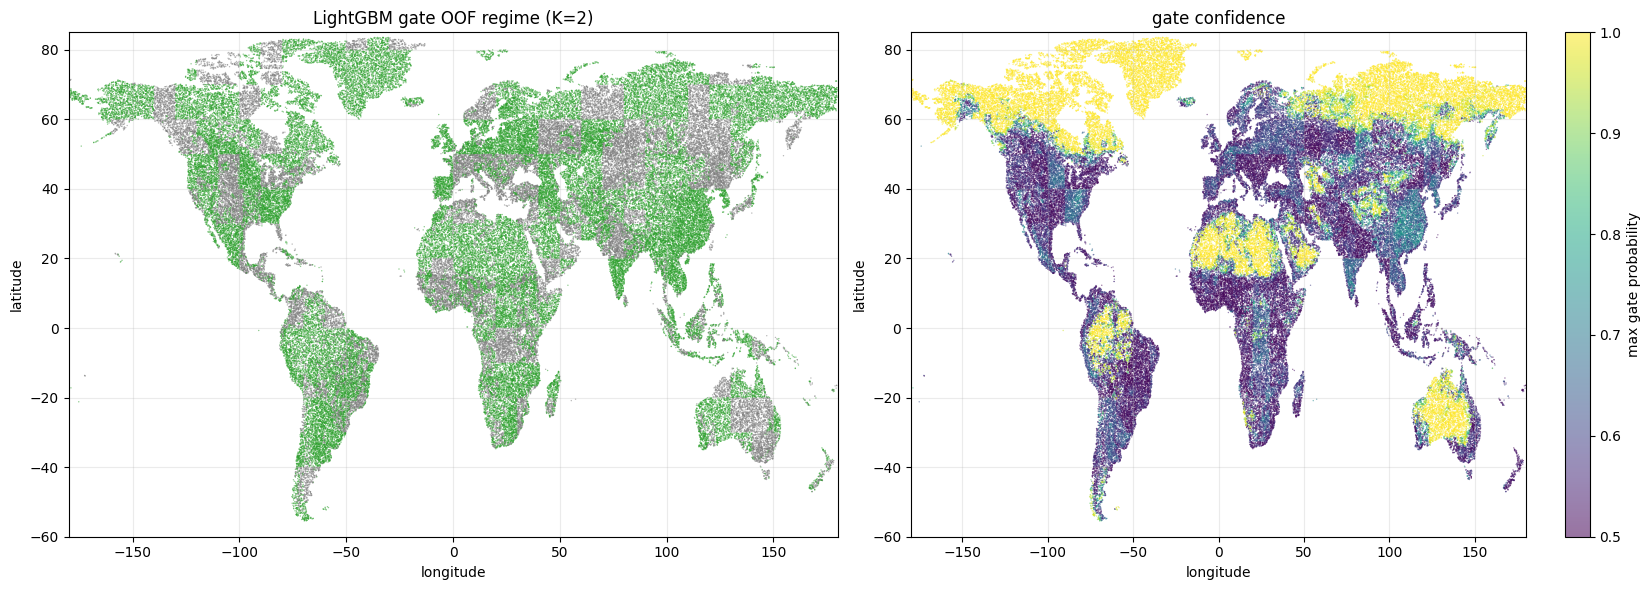

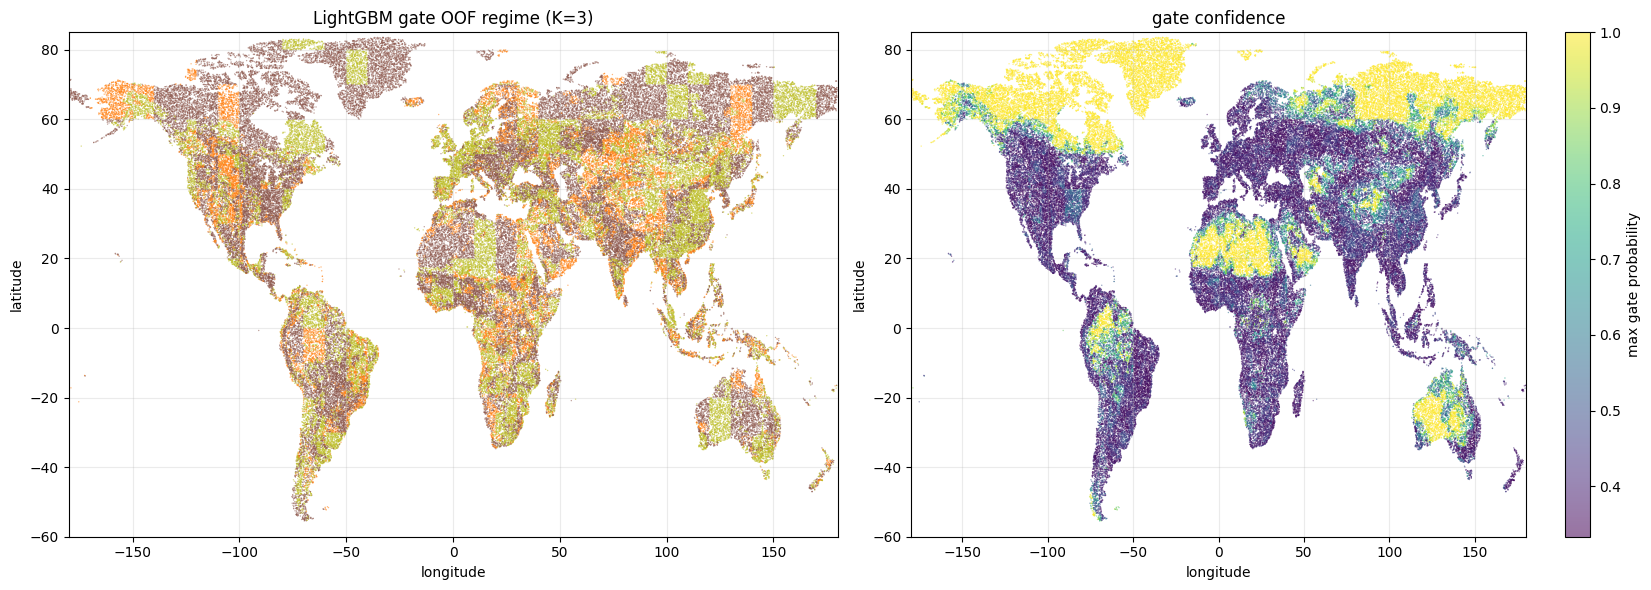

In [12]:
plot_rng = np.random.default_rng(REGIME_RANDOM_SEED + 900)
max_plot_n = 120_000
plot_idx = (
    plot_rng.choice(len(raw_analysis_sample), max_plot_n, replace=False)
    if len(raw_analysis_sample) > max_plot_n
    else np.arange(len(raw_analysis_sample))
)
for n_regimes, result in moe_results.items():
    points = raw_analysis_sample.iloc[plot_idx]
    state_values = result["state"][plot_idx]
    confidence_values = result["confidence"][plot_idx]
    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    state_plot = axes[0].scatter(
        points["lon"], points["lat"], c=state_values, s=1.0, alpha=0.55,
        cmap="tab10", vmin=-0.5, vmax=n_regimes - 0.5, linewidths=0,
    )
    axes[0].set_title(f"LightGBM gate OOF regime (K={n_regimes})")
    axes[0].set_xlabel("longitude")
    axes[0].set_ylabel("latitude")
    axes[0].set_xlim(-180, 180)
    axes[0].set_ylim(-60, 85)
    axes[0].grid(alpha=0.25)
    confidence_plot = axes[1].scatter(
        points["lon"], points["lat"], c=confidence_values, s=1.0, alpha=0.55,
        cmap="viridis", vmin=1.0 / n_regimes, vmax=1.0, linewidths=0,
    )
    axes[1].set_title("gate confidence")
    axes[1].set_xlabel("longitude")
    axes[1].set_ylabel("latitude")
    axes[1].set_xlim(-180, 180)
    axes[1].set_ylim(-60, 85)
    axes[1].grid(alpha=0.25)
    fig.colorbar(confidence_plot, ax=axes[1], label="max gate probability")
    plt.tight_layout()
    plt.show()



## 【セル12】結果の保存と解釈

このnotebookの主な判定基準は、pooled raw_crop_wx LightGBMに対する空間OOFの改善です。
Kが大きいほど訓練データへの適合は上がりやすいため、全体R²だけでなくfold別の改善、
gateの信頼度、レジームのセル数も確認してください。

この後、最良のKを選んで、各レジームの専門LightGBMに対してSHAPを計算します。
SHAPはレジームを作るためではなく、レジームごとの反応差を説明するために使います。


In [13]:
regime_oof_table = raw_analysis_sample[
    ["row", "col", "lat", "lon", "spatial_block", "presence", "cropland_fraction"]
].copy()
regime_oof_table["pooled_prediction"] = pooled_prediction
regime_oof_table["pooled_residual"] = y_fraction - pooled_prediction
for n_regimes, result in moe_results.items():
    regime_oof_table[f"k{n_regimes}_hard_prediction"] = result["hard_prediction"]
    regime_oof_table[f"k{n_regimes}_soft_prediction"] = result["soft_prediction"]
    regime_oof_table[f"k{n_regimes}_hard_residual"] = y_fraction - result["hard_prediction"]
    regime_oof_table[f"k{n_regimes}_soft_residual"] = y_fraction - result["soft_prediction"]
    regime_oof_table[f"k{n_regimes}_state"] = result["state"]
    regime_oof_table[f"k{n_regimes}_confidence"] = result["confidence"]
moe_global_metrics_df.to_csv(
    REGIME_OUTPUT_DIR / "lightgbm_regime_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
moe_fold_metrics_df.to_csv(
    REGIME_OUTPUT_DIR / "lightgbm_regime_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
moe_fold_summary_df.to_csv(
    REGIME_OUTPUT_DIR / "lightgbm_regime_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
moe_distribution_df.to_csv(
    REGIME_OUTPUT_DIR / "lightgbm_regime_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)
regime_oof_table.to_csv(
    REGIME_OUTPUT_DIR / "lightgbm_regime_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
print("保存先:")
print(REGIME_OUTPUT_DIR)



保存先:
C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\lightgbm_latent_regime_moe
